In [1]:
import os
import cv2
import glob
import math
import time
import h5py
import random
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import multiprocessing
import tensorflow as tf
from pathlib import Path
import concurrent.futures
import keras.backend as K
from time import perf_counter
from functools import lru_cache
import matplotlib.pyplot as plt
from keras import layers, models
from keras.optimizers import Adam
from PIL import Image, ImageEnhance
from joblib import Parallel, delayed
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from keras.metrics import Precision, Recall, AUC
from keras.callbacks import LearningRateScheduler
from keras.utils import plot_model, to_categorical
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report

In [3]:
!pip install -q kagglehub
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'figshare-brain-tumor-dataset' dataset.
Dataset downloaded to: /kaggle/input/figshare-brain-tumor-dataset


In [14]:
import os

for root, dirs, files in os.walk(path):
    if files:
        print(root)
        print(files[:5])   # show first few files
        print("-"*50)

/kaggle/input/figshare-brain-tumor-dataset/dataset
['README.txt', 'cvind.mat']
--------------------------------------------------
/kaggle/input/figshare-brain-tumor-dataset/dataset/data
['2912.mat', '2011.mat', '3027.mat', '1912.mat', '3023.mat']
--------------------------------------------------


In [6]:
class BrainTumorDataset:
    def __init__(self, data_dir):
        self.file_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".mat")]
        self.label_map = {1: 'meningioma', 2: 'glioma', 3: 'pituitary tumor'}

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        with h5py.File(file_path, 'r') as f:
            cjdata = f['cjdata']
            image = np.array(cjdata['image']).T
            mask = np.array(cjdata['tumorMask']).T
            label = int(np.array(cjdata['label'])[0][0])
            pid = ''.join([chr(c[0]) for c in np.array(cjdata['PID'])])

        return {
            'image': image,
            'mask': mask,
            'label': label,
            'class_name': self.label_map.get(label, 'unknown'),
            'pid': pid,
            'filename': os.path.basename(file_path)
        }

In [7]:
import os
import kagglehub

path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")

# Search for folder containing .mat files
data_dir = None

for root, dirs, files in os.walk(path):
    if any(f.endswith(".mat") for f in files):
        data_dir = root
        break

if data_dir is None:
    raise FileNotFoundError("No .mat files found in downloaded dataset.")

print("Using:", data_dir)

dataset = BrainTumorDataset(data_dir)

Using Colab cache for faster access to the 'figshare-brain-tumor-dataset' dataset.
Using: /kaggle/input/figshare-brain-tumor-dataset/dataset


In [11]:
import os

print("Downloaded path:", path)

for root, dirs, files in os.walk(path):
    print("\nFolder:", root)
    print("Number of files:", len(files))
    print(files[:10])   # first 10 files only

Downloaded path: /kaggle/input/figshare-brain-tumor-dataset

Folder: /kaggle/input/figshare-brain-tumor-dataset
Number of files: 0
[]

Folder: /kaggle/input/figshare-brain-tumor-dataset/dataset
Number of files: 2
['README.txt', 'cvind.mat']

Folder: /kaggle/input/figshare-brain-tumor-dataset/dataset/data
Number of files: 3064
['2912.mat', '2011.mat', '3027.mat', '1912.mat', '3023.mat', '101.mat', '1194.mat', '851.mat', '2106.mat', '1850.mat']


In [15]:
import os

candidate_dirs = []

for root, dirs, files in os.walk(path):
    mat_files = [f for f in files if f.endswith(".mat")]

    # Ignore folders that only contain cvind.mat
    image_files = [f for f in mat_files if f != "cvind.mat"]

    if len(image_files) > 10:
        candidate_dirs.append((root, len(image_files)))

print(candidate_dirs)

[('/kaggle/input/figshare-brain-tumor-dataset/dataset/data', 3064)]


In [16]:
data_dir = candidate_dirs[0][0]

dataset = BrainTumorDataset(data_dir)

print(len(dataset))

3064


In [17]:
import numpy as np
import tensorflow as tf

IMG_SIZE = (224, 224)

all_images = []
all_labels = []

print("Number of files:", len(dataset))

for i in range(len(dataset)):
    sample = dataset[i]

    img = sample["image"]
    label = sample["label"] - 1   # convert 1,2,3 -> 0,1,2

    # Make sure image is float32
    img = img.astype(np.float32)

    # Normalize
    img = img / np.max(img)

    # Add channel dimension
    img = np.expand_dims(img, axis=-1)

    # Resize
    img = tf.image.resize(img, IMG_SIZE).numpy()

    # Convert grayscale -> RGB
    img = np.repeat(img, 3, axis=-1)

    all_images.append(img)
    all_labels.append(label)

all_images = np.array(all_images, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int32)

print("Images:", all_images.shape)
print("Labels:", all_labels.shape)
print("Unique labels:", np.unique(all_labels))

Number of files: 3064
Images: (3064, 224, 224, 3)
Labels: (3064,)
Unique labels: [0 1 2]


In [19]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

num_classes = 3

all_labels = to_categorical(all_labels, num_classes)

X_temp, X_test, y_temp, y_test = train_test_split(
    all_images,
    all_labels,
    test_size=0.20,
    random_state=42,
    stratify=np.argmax(all_labels, axis=1)
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(1960, 224, 224, 3)
(1960, 3)
(491, 224, 224, 3)
(491, 3)
(613, 224, 224, 3)
(613, 3)


In [20]:
BATCH_SIZE = 8

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
)

In [21]:
from collections import Counter
import numpy as np

label_map = {
    0: "meningioma",
    1: "glioma",
    2: "pituitary tumor"
}

train_counts = Counter(np.argmax(y_train, axis=1))
val_counts = Counter(np.argmax(y_val, axis=1))
test_counts = Counter(np.argmax(y_test, axis=1))

print(f"{'Class':<20}{'Train':<10}{'Validation':<12}{'Test':<10}")
print("-"*55)

for i in range(3):
    print(f"{label_map[i]:<20}{train_counts[i]:<10}{val_counts[i]:<12}{test_counts[i]:<10}")

Class               Train     Validation  Test      
-------------------------------------------------------
meningioma          453       113         142       
glioma              912       229         285       
pituitary tumor     595       149         186       


In [22]:
from collections import Counter

labels = np.argmax(all_labels, axis=1)

counts = Counter(labels)

label_map = {
    0: "meningioma",
    1: "glioma",
    2: "pituitary tumor"
}

for i in range(3):
    print(label_map[i], counts[i])

meningioma 708
glioma 1426
pituitary tumor 930


In [23]:
import keras.backend as K
from tensorflow.keras.layers import LeakyReLU

def cbam_block(cbam_feature, ratio=8):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """

    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = spatial_attention(cbam_feature)
    return cbam_feature

def channel_attention(input_feature, ratio=8):
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = input_feature.shape[channel_axis]

    shared_layer_one = Dense(channel//ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')
    shared_layer_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1,1,channel))(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel)
    avg_pool = shared_layer_one(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel//ratio)
    avg_pool = shared_layer_two(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1,1,channel))(max_pool)
    assert max_pool.shape[1:] == (1,1,channel)
    max_pool = shared_layer_one(max_pool)
    assert max_pool.shape[1:] == (1,1,channel//ratio)
    max_pool = shared_layer_two(max_pool)
    assert max_pool.shape[1:] == (1,1,channel)

    cbam_feature = Add()([avg_pool,max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

In [24]:
import tensorflow as tf

def spatial_attention(input_feature):
    kernel_size = 7

    if K.image_data_format() == "channels_first":
        channel = input_feature.shape[1]
        cbam_feature = Permute((2, 3, 1))(input_feature)
    else:
        channel = input_feature.shape[-1]
        cbam_feature = input_feature

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True), output_shape=lambda s: (s[0], s[1], s[2], 1))(cbam_feature)
    assert avg_pool.shape[-1] == 1
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True), output_shape=lambda s: (s[0], s[1], s[2], 1))(cbam_feature)
    assert max_pool.shape[-1] == 1
    concat = Concatenate(axis=3)([avg_pool, max_pool])
    assert concat.shape[-1] == 2
    cbam_feature = Conv2D(filters=1,
                          kernel_size=kernel_size,
                          strides=1,
                          padding='same',
                          activation='sigmoid',
                          kernel_initializer='he_normal',
                          use_bias=False)(concat)
    assert cbam_feature.shape[-1] == 1

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])


def residual_block(y, nb_channels, _strides=(1, 1), _project_shortcut=False):
    shortcut = y

    # down-sampling is performed with a stride of 2
    y = Conv2D(nb_channels, kernel_size=(3, 3), strides=_strides, padding='same')(y)
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)

    y = Conv2D(nb_channels, kernel_size=(3, 3), strides=(1, 1), padding='same')(y)
    y = BatchNormalization()(y)

    # identity shortcuts used directly when the input and output are of the same dimensions
    if _project_shortcut or _strides != (1, 1):
        # when the dimensions increase projection shortcut is used to match dimensions (done by 1×1 convolutions)
        # when the shortcuts go across feature maps of two sizes, they are performed with a stride of 2
        shortcut = Conv2D(nb_channels, kernel_size=(1, 1), strides=_strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    y = add([shortcut, y])
    y = LeakyReLU()(y)

    return y

In [25]:
from albumentations import *
from skimage.transform import resize


from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

from keras.layers import *
from keras.callbacks import *
from keras.optimizers import *
from keras.models import load_model, Model

def create_model():
    input_shape = (224, 224, 3)  # Example shape, adjust according to your input size

    # Ensure consistent data type
    dtype = 'float32'

    drop_rate = 0.3

    init = Input(shape=input_shape, dtype=dtype)
    x = Conv2D(32, (3, 3), activation=None, padding='same', dtype=dtype)(init)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(32, (3, 3), activation=None, padding='same', dtype=dtype)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x1 = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3, 3), activation=None, padding='same', dtype=dtype)(x1)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x)  # Assuming cbam_block is defined
    x = residual_block(x, 64)  # Assuming residual_block is defined
    x2 = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3, 3), activation=None, padding='same', dtype=dtype)(x2)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x)  # Assuming cbam_block is defined
    x = residual_block(x, 128)  # Assuming residual_block is defined
    x3 = MaxPooling2D((2,2))(x)

    ginp1 = UpSampling2D(size=(2, 2), interpolation='bilinear')(x1)
    ginp2 = UpSampling2D(size=(4, 4), interpolation='bilinear')(x2)
    ginp3 = UpSampling2D(size=(8, 8), interpolation='bilinear')(x3)

    hypercolumn = Concatenate()([ginp1, ginp2, ginp3])
    gap = GlobalAveragePooling2D()(hypercolumn)

    x = Dense(256, activation=None, dtype=dtype)(gap)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(drop_rate)(x)

    x = Dense(256, activation=None, dtype=dtype)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    output = Dense(3, activation='softmax')(x)

    model = Model(init, output)
    return model


model = create_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 8)   │        520 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        576 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 605,823 (2.31 MB)

 Trainable params: 603,519 (2.30 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [26]:
plot_model(model, show_shapes=True)

In [27]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras import backend as K

def create_metrics():
    @tf.function
    def f1_score(y_true, y_pred):
        tp = true_positive(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())

        return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

    @tf.function
    def specificity(y_true, y_pred):
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        return tn / (tn + fp + tf.keras.backend.epsilon())

    @tf.function
    def sensitivity(y_true, y_pred):
        tp = true_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)
        return tp / (tp + fn + tf.keras.backend.epsilon())

    @tf.function
    def mcc(y_true, y_pred):
        tp = true_positive(y_true, y_pred)
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        numerator = (tp * tn - fp * fn)
        denominator = tf.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        return numerator / (denominator + tf.keras.backend.epsilon())

    @tf.function
    def true_positive(y_true, y_pred):
        y_pred_pos, _, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_pos * y_pred_pos)

    @tf.function
    def false_positive(y_true, y_pred):
        y_pred_pos, _, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_neg * y_pred_pos)

    @tf.function
    def false_negative(y_true, y_pred):
        _, y_pred_neg, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_pos * y_pred_neg)

    @tf.function
    def true_negative(y_true, y_pred):
        _, y_pred_neg, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return tf.reduce_sum(y_neg * y_pred_neg)

    @tf.function
    def calculate_confusion_matrix(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_pred_pos = tf.round(tf.clip_by_value(y_pred, 0, 1))
        y_pred_neg = 1 - y_pred_pos
        y_pos = tf.round(tf.clip_by_value(y_true, 0, 1))
        y_neg = 1 - y_pos
        return y_pred_pos, y_pred_neg, y_pos, y_neg

    # Return individual functions directly (custom ones stay as functions)
    return (
        Precision(),
        Recall(),
        f1_score,
        specificity,
        sensitivity,
        mcc,
        AUC()
    )


In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=["accuracy", *create_metrics()]
)

In [29]:
class TimeCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.perf_counter()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.perf_counter() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

    def on_train_end(self, logs=None):
        self.total_train_time = time.perf_counter() - self.train_start_time

time_callback = TimeCallback()

In [32]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Automatically get the correct input size
_, H, W, C = model.input_shape

@tf.function
def model_fn(x):
    return model(x)

concrete_func = model_fn.get_concrete_function(
    tf.TensorSpec([1, H, W, C], tf.float32)
)

frozen_func = convert_variables_to_constants_v2(concrete_func)
graph = frozen_func.graph

with graph.as_default():
    flops = tf.compat.v1.profiler.profile(
        graph=graph,
        options=tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    )

print("="*60)
print(f"Input Shape : {model.input_shape}")
print(f"Parameters  : {model.count_params():,}")
print(f"Params (M)  : {model.count_params()/1e6:.3f}")
print(f"FLOPs       : {flops.total_float_ops:,}")
print(f"GFLOPs      : {flops.total_float_ops/1e9:.3f}")
print("="*60)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Input Shape : (None, 224, 224, 3)
Parameters  : 605,823
Params (M)  : 0.606
FLOPs       : 5,679,660,674
GFLOPs      : 5.680


In [ ]:
TOTAL_EPOCHS = 25

start_time = perf_counter()
history = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    validation_data=val_ds,
    callbacks=[time_callback]
)
end_time = perf_counter()

Epoch 1/25


I0000 00:00:1748193195.900605      93 service.cc:148] XLA service 0x7ab61806f030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748193195.901320      93 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748193197.234130      93 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/245 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.3125 - auc: 0.5254 - f1_score: 0.2714 - loss: 1.3108 - mcc: -0.0486 - precision: 0.2967 - recall: 0.2500 - sensitivity: 0.2500 - specificity: 0.7031   

I0000 00:00:1748193206.798673      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.5757 - auc: 0.7616 - f1_score: 0.5240 - loss: 0.9180 - mcc: 0.3587 - precision: 0.6371 - recall: 0.4554 - sensitivity: 0.4554 - specificity: 0.8708 - val_accuracy: 0.3707 - val_auc: 0.5263 - val_f1_score: 0.3266 - val_loss: 1.2559 - val_mcc: 0.1036 - val_precision: 0.4290 - val_recall: 0.2709 - val_sensitivity: 0.2749 - val_specificity: 0.8199
Epoch 2/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.7162 - auc: 0.8755 - f1_score: 0.6921 - loss: 0.6798 - mcc: 0.5633 - precision: 0.7508 - recall: 0.6485 - sensitivity: 0.6485 - specificity: 0.8924 - val_accuracy: 0.4644 - val_auc: 0.7468 - val_f1_score: 0.4675 - val_loss: 1.0684 - val_mcc: 0.2170 - val_precision: 0.4814 - val_recall: 0.4481 - val_sensitivity: 0.4503 - val_specificity: 0.7611
Epoch 3/25
245/245 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.7531 - auc: 0.9011 - f1_score: 0.7375 - loss: 0.6048 - mcc: 0.6233 - precision: 0.7843 - recall: 0.6997 - sensitivi

In [ ]:
execution_time_parts = []
avg_time_parts = []

for unit in [(3600, 'hours'), (60, 'minutes'), (1, 'seconds'), (0.001, 'milliseconds')]:
    total_value = int(time_callback.total_train_time // unit[0])
    avg_value = int(np.mean(time_callback.epoch_times) // unit[0])

    if total_value > 0 or unit[0] == 0.001:
        execution_time_parts.append((total_value, unit[1]))
    if avg_value > 0 or unit[0] == 0.001:
        avg_time_parts.append((avg_value, unit[1]))

    time_callback.total_train_time -= total_value * unit[0]
    time_callback.epoch_times = [time - avg_value * unit[0] for time in time_callback.epoch_times]

execution_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in execution_time_parts if value > 0
])

avg_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in avg_time_parts if value > 0
])

print(f"Model training took {execution_time_string}")
print(f"Average time per epoch: {avg_time_string}")

Model training took 07 minutes, 56 seconds, 439 milliseconds
Average time per epoch: 19 seconds, 40 milliseconds


In [ ]:
_ = model.evaluate(test_ds)

77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8582 - auc: 0.9608 - f1_score: 0.8582 - loss: 0.3830 - mcc: 0.7884 - precision: 0.8640 - recall: 0.8522 - sensitivity: 0.8522 - specificity: 0.9329


In [ ]:
def plot_metrics(hist, metric_name_list):
    num_metrics = len(metric_name_list)

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))

    rng = range(1, len(hist.history[metric_name_list[0]]) + 1)

    for ax, metric_n in zip(axes, metric_name_list):
        metric = hist.history[metric_n]
        v_metric = hist.history[f"val_{metric_n}"]

        ax.plot(rng, metric, label=metric_n)
        ax.plot(rng, v_metric, label=f"val_{metric_n}")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_n in ("auc", "mcc"):
            ax.set_ylabel(metric_n.upper())
            ax.set_title(metric_n.upper() + " vs Epochs")
        else:
            ax.set_ylabel(metric_n.capitalize())
            ax.set_title(metric_n.capitalize() + " vs Epochs")

        max_loss = max(max(metric), max(v_metric))
        min_loss = min(min(metric), min(v_metric))
        y_max = math.ceil(max_loss)

        if min_loss > 0 or max_loss > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_loss, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlim(1, len(metric))

    plt.tight_layout()

    plt.show()

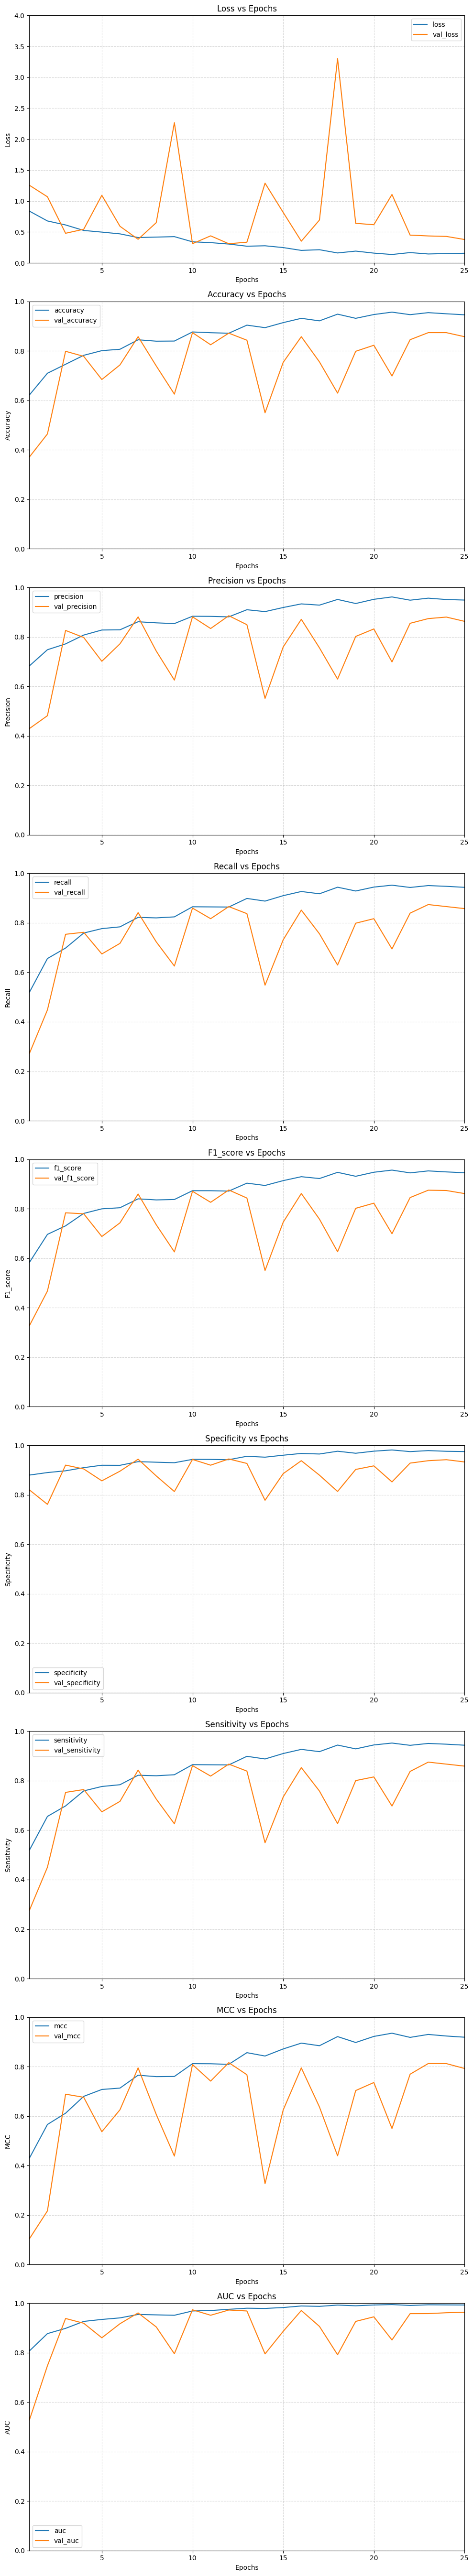

In [ ]:
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score",
                "specificity", "sensitivity", "mcc", "auc"]
plot_metrics(history, metric_names)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import tensorflow as tf

# Define class names
class_names = ['meningioma', 'glioma', 'pituitary tumor']

def generate_classification_report(model, test_dataset, target_names):
    predicted_labels = []
    true_labels = []

    for batch_data, batch_true_labels in test_dataset:
        batch_predicted_labels = model.predict(batch_data)
        batch_predicted_labels = np.argmax(batch_predicted_labels, axis=1)

        if batch_true_labels.shape[-1] > 1:
            batch_true_labels = tf.argmax(batch_true_labels, axis=1)

        predicted_labels.extend(batch_predicted_labels)
        true_labels.extend(batch_true_labels.numpy())

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=target_names,
        digits=4,
        zero_division=1
    )

    accuracy = accuracy_score(true_labels, predicted_labels)
    num_errors = np.sum(np.array(true_labels) != np.array(predicted_labels))

    print(report)
    print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy*100:6.2f}%')

    return true_labels, predicted_labels

# Run the evaluation
true_labels, predicted_labels = generate_classification_report(
    model,
    test_ds,
    target_names=class_names
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━

In [ ]:
def confusion_matrix(true_labels, predicted_labels, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    np.add.at(cm, (true_labels, predicted_labels), 1)
    return cm

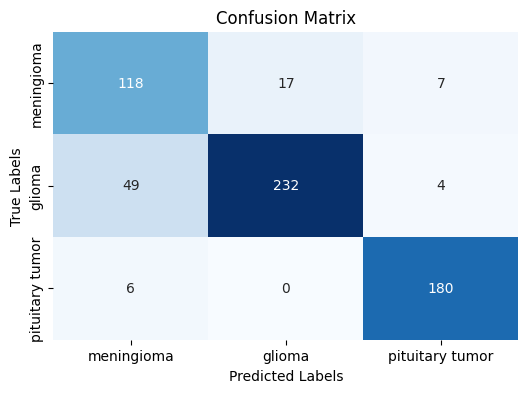

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels, 3)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()